# Pipeline Cascada — análisis de resultados

Evalúa el output de `pipeline_agentes.py` (`pipeline_cascada.csv`) contra `validacion_real.csv`.

Estructura:
1. Carga + merge con ground truth.
2. Métricas globales (top-1, top-2, multi-label recall).
3. Por-PB: precision / recall / F1 + matriz de confusión.
4. Análisis de errores: confusiones, manejo de None, parse errors.
5. Comparación de rutas (`fast_skip_consensus` vs `llm_judged`).
6. Calidad del Agente 1 (extractor): methodology, frame, # items, alineación con la decisión final.
7. Scorer determinista: ¿añade señal real o solo ruido?
8. Timing.
9. Inspección manual de los peores casos.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', 220)
sns.set_theme(style='whitegrid')

## 1. Carga + merge con ground truth

In [2]:
ROOT = Path.cwd().resolve().parents[2]
RES_PATH = ROOT / 'nlp' / 'llm' / 'outputs' / 'pipeline_cascada' / 'pipeline_cascada.csv'
GT_PATH = ROOT / 'nlp' / 'llm' / 'outputs' / 'ground_truth' / 'validacion_real.csv'
CORPUS_PATH = ROOT / 'data' / 'corpus' / 'master_corpus_mixto_1000_clean_enriched.csv'

# keep_default_na=False evita que el string 'None' (predicción válida) se convierta en NaN.
res = pd.read_csv(RES_PATH, keep_default_na=False)
gt = pd.read_csv(GT_PATH, sep=';', encoding='utf-8')
corpus = pd.read_csv(CORPUS_PATH)

print(f'Pipeline rows : {len(res)}')
print(f'GT rows       : {len(gt)}')
print(f'Corpus rows   : {len(corpus)}')

Pipeline rows : 157
GT rows       : 208
Corpus rows   : 696


In [ ]:
PB_CODES = [f'PB{i}' for i in range(1, 10)]

def to_pb(x):
    """1.0 / '1' / np.nan / '' -> 'PB1' / 'None'."""
    if pd.isna(x) or str(x).strip() in ('', 'nan'):
        return 'None'
    s = str(x).strip().replace('.0', '')
    return f'PB{s}' if s.isdigit() else s

gt = gt.copy()
gt['doc_id'] = gt['doc_id'].astype(str)
gt['gt_pb'] = gt['1stpb'].apply(to_pb)
gt['gt_2nd'] = gt['2ndpb'].apply(to_pb)
gt['gt_3rd'] = gt['3rdpb'].apply(to_pb)
gt['gt_set'] = gt[['gt_pb','gt_2nd','gt_3rd']].apply(
    lambda r: {x for x in r if x in PB_CODES}, axis=1
)

res = res.copy()
res['doc_id'] = res['doc_id'].astype(str)
# Si el pipeline corrio con Agente 4, usamos final_primary_pb (override-aware).
# Si no, caemos a llm_primary_pb (compatible con CSVs antiguos).
if 'final_primary_pb' in res.columns:
    res['pred_primary'] = res['final_primary_pb'].replace('', pd.NA).fillna(res['llm_primary_pb']).replace('', 'None')
    print("Usando final_primary_pb (post-critic) como predicción primaria.")
else:
    res['pred_primary'] = res['llm_primary_pb'].replace('', 'None')
    print("CSV sin Agente 4: usando llm_primary_pb como predicción primaria.")

def split_secondary(s):
    if not isinstance(s, str) or s.strip() in ('', 'None'):
        return []
    return [x.strip() for x in re.split(r'[;,]', s) if x.strip() in PB_CODES]

res['pred_secondary'] = res['llm_secondary_pbs'].apply(split_secondary)
res['pred_set'] = res.apply(
    lambda r: ({r['pred_primary']} | set(r['pred_secondary'])) - {'None', 'Error', 'ParseError'},
    axis=1,
)

df = res.merge(gt[['doc_id','gt_pb','gt_2nd','gt_3rd','gt_set','nombre_doc']], on='doc_id', how='left')
df_eval = df.dropna(subset=['gt_pb']).copy()
print(f'En CSV de pipeline: {len(df)}')
print(f'Con GT match     : {len(df_eval)}')
print(f'Sin GT (excluir) : {len(df) - len(df_eval)}')

## 2. Métricas globales

- **Top-1**: `pred_primary == gt_pb` (1ª PB exacta).
- **Top-2**: `gt_pb` aparece como primary o secondary.
- **Multi-label recall**: ¿cuántos de los PBs de GT (1ª/2ª/3ª) están en el conjunto predicho `{primary} ∪ secondary`?

In [4]:
df_eval['ok_top1'] = df_eval['pred_primary'] == df_eval['gt_pb']
df_eval['ok_top2'] = df_eval.apply(
    lambda r: r['gt_pb'] == r['pred_primary'] or r['gt_pb'] in r['pred_secondary'],
    axis=1,
)
df_eval['gt_size']   = df_eval['gt_set'].apply(len)
df_eval['ml_recall'] = df_eval.apply(
    lambda r: (len(r['gt_set'] & r['pred_set']) / len(r['gt_set'])) if r['gt_set'] else np.nan,
    axis=1,
)

n = len(df_eval)
metrics = pd.Series({
    'n_papers'             : n,
    'top1_accuracy'        : df_eval['ok_top1'].mean(),
    'top2_accuracy'        : df_eval['ok_top2'].mean(),
    'multilabel_recall_avg': df_eval['ml_recall'].mean(),
    'top1_acc_excl_none'   : df_eval[df_eval['gt_pb'] != 'None']['ok_top1'].mean(),
    'top1_acc_only_none'   : df_eval[df_eval['gt_pb'] == 'None']['ok_top1'].mean(),
})
metrics.round(3)

n_papers                 150.000
top1_accuracy              0.640
top2_accuracy              0.680
multilabel_recall_avg      0.641
top1_acc_excl_none         0.606
top1_acc_only_none         0.706
dtype: float64

## 3. Por-PB: precision / recall / F1 + matriz de confusión

Tratamos la 1ª PB de GT vs la primary del modelo como una clasificación multiclase (10 clases incluyendo `None`).

In [5]:
labels = PB_CODES + ['None']

def per_class_prf(y_true, y_pred, label):
    tp = ((y_true == label) & (y_pred == label)).sum()
    fp = ((y_true != label) & (y_pred == label)).sum()
    fn = ((y_true == label) & (y_pred != label)).sum()
    support = (y_true == label).sum()
    p = tp / (tp + fp) if (tp + fp) else 0
    r = tp / (tp + fn) if (tp + fn) else 0
    f1 = 2*p*r / (p + r) if (p + r) else 0
    return support, p, r, f1

rows = []
for lab in labels:
    s, p, r, f1 = per_class_prf(df_eval['gt_pb'], df_eval['pred_primary'], lab)
    rows.append({'label': lab, 'support': s, 'precision': p, 'recall': r, 'f1': f1})
prf = pd.DataFrame(rows).set_index('label')
prf.round(3)

,support,precision,recall,f1
label,,,,
PB1,24,0.579,0.458,0.512
PB2,8,0.667,0.500,0.571
PB3,8,0.714,0.625,0.667
PB4,10,0.444,0.800,0.571
PB5,4,0.375,0.750,0.500
PB6,4,0.500,0.500,0.500
PB7,13,0.667,0.462,0.545
PB8,7,1.000,0.286,0.444
PB9,21,0.760,0.905,0.826


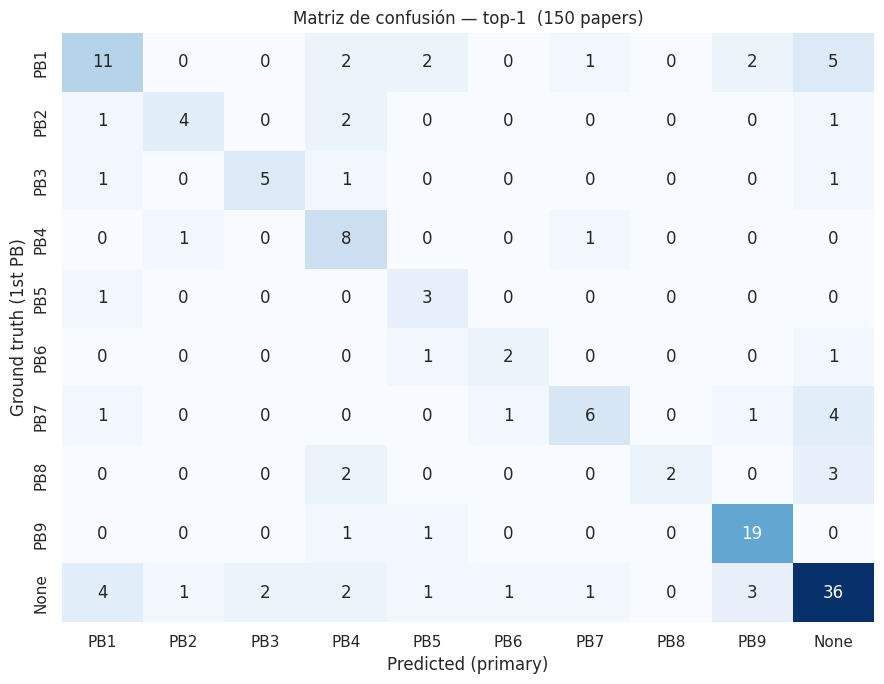

In [6]:
cm = pd.crosstab(df_eval['gt_pb'], df_eval['pred_primary']).reindex(index=labels, columns=labels, fill_value=0)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
ax.set_xlabel('Predicted (primary)')
ax.set_ylabel('Ground truth (1st PB)')
ax.set_title(f'Matriz de confusión — top-1  ({len(df_eval)} papers)')
plt.tight_layout()
plt.show()

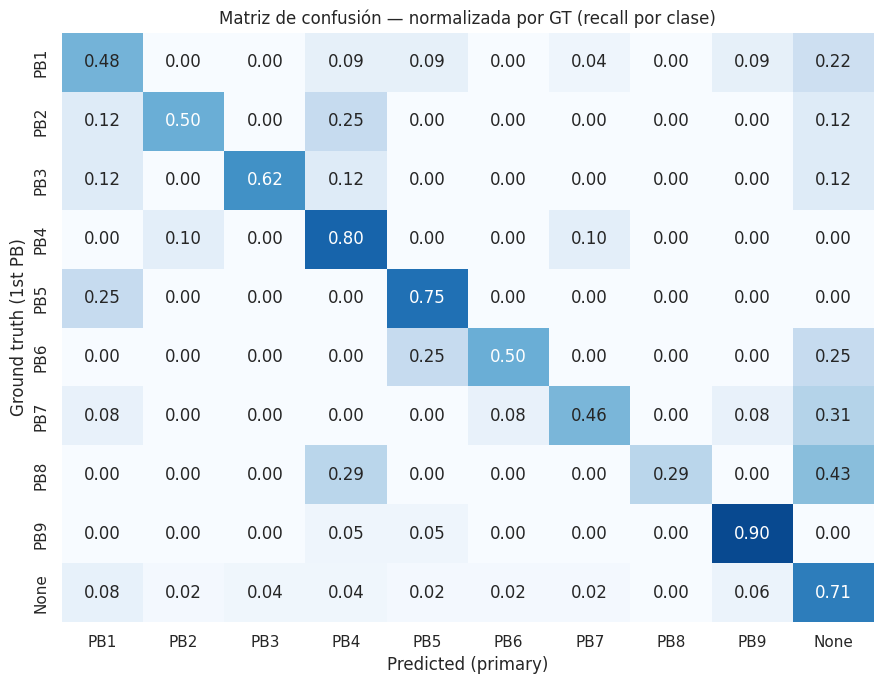

In [7]:
# Misma matriz, normalizada por filas (recall por clase).
cm_norm = cm.div(cm.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax, cbar=False, vmin=0, vmax=1)
ax.set_xlabel('Predicted (primary)')
ax.set_ylabel('Ground truth (1st PB)')
ax.set_title('Matriz de confusión — normalizada por GT (recall por clase)')
plt.tight_layout()
plt.show()

## 4. Análisis de errores

- **Confusiones top**: pares (gt, pred) más frecuentes cuando hay error.
- **None mismanagement**: cuántos GT=None acaban como PBx (falso positivo) y cuántos GT=PBx acaban como None (falso negativo).
- **Parse / agent errors**.

In [8]:
errs = df_eval[~df_eval['ok_top1']].copy()
top_conf = errs.groupby(['gt_pb', 'pred_primary']).size().sort_values(ascending=False).head(15)
top_conf.to_frame('n_errors')

n_errors
gt_pb pred_primary          
PB1   None                 5
None  PB1                  4
PB7   None                 4
PB8   None                 3
None  PB9                  3
PB1   PB4                  2
PB8   PB4                  2
PB1   PB9                  2
      PB5                  2
PB2   PB4                  2
None  PB3                  2
      PB4                  2
      PB7                  1
PB5   PB1                  1
PB9   PB4                  1

In [9]:
none_block = pd.DataFrame({
    'GT=None & pred=None  (TN)' : [(df_eval['gt_pb'].eq('None') & df_eval['pred_primary'].eq('None')).sum()],
    'GT=None & pred=PBx   (FP)' : [(df_eval['gt_pb'].eq('None') & df_eval['pred_primary'].ne('None') & df_eval['pred_primary'].isin(PB_CODES)).sum()],
    'GT=PBx  & pred=None  (FN)' : [(df_eval['gt_pb'].ne('None') & df_eval['pred_primary'].eq('None')).sum()],
    'GT=PBx  & pred=PBx   (any)': [(df_eval['gt_pb'].ne('None') & df_eval['pred_primary'].isin(PB_CODES)).sum()],
}).T.rename(columns={0:'count'})
none_block

,count
GT=None & pred=None (TN),36
GT=None & pred=PBx (FP),15
GT=PBx & pred=None (FN),15
GT=PBx & pred=PBx (any),83


In [10]:
tech_errors = pd.Series({
    'agent1_parse_error': (df['agent1_parse_error'].astype(str).str.strip() != '').sum(),
    'agent1_error'      : (df['agent1_error'].astype(str).str.strip() != '').sum(),
    'agent3_error'      : (df['agent3_error'].astype(str).str.strip() != '').sum(),
    'pred_ParseError'   : (df['pred_primary'] == 'ParseError').sum(),
    'pred_Error'        : (df['pred_primary'] == 'Error').sum(),
})
tech_errors

agent1_parse_error    0
agent1_error          0
agent3_error          1
pred_ParseError       1
pred_Error            0
dtype: int64

## 5. Rutas: `fast_skip_consensus` vs `llm_judged`

El consensus skip es el atajo barato (Agent1=0 items + frame no-bio + scorer sin matches → None directo). ¿Acierta?

In [11]:
route_summary = (
    df_eval.groupby('route')
    .agg(n=('doc_id', 'size'),
         top1_acc=('ok_top1', 'mean'),
         top2_acc=('ok_top2', 'mean'),
         avg_time_s=('total_time_s', 'mean'))
    .round(3)
)
route_summary

,n,top1_acc,top2_acc,avg_time_s
route,,,,
fast_skip_consensus,5,0.800,0.800,4.755
llm_judged,145,0.634,0.676,13.602


In [12]:
skipped = df_eval[df_eval['route'] == 'fast_skip_consensus'][['doc_id','gt_pb','pred_primary','ok_top1','agent1_frame','agent1_n_items','kw_top_pbs','nombre_doc']]
skipped

,doc_id,gt_pb,pred_primary,ok_top1,agent1_frame,agent1_n_items,kw_top_pbs,nombre_doc
16,a3d6daa1a396,None,None,True,economics,0,,Economic and social vulnerability because of Covid-19_ poverty and food security.pdf
82,61c5ef71efb6,PB8,None,False,law_policy,0,,Legal Lamination to Transboundary Movement of Plastic Pollutants.pdf
112,b04f1061de65,None,None,True,social_sciences,0,,The meaning of life together and inter-relationship in business.pdf
114,763c5ac1d0cb,None,None,True,economics,0,,An Analysis on Sustainable Development and Green Economy.pdf
126,b98dbc59db77,None,None,True,social_sciences,0,,On Organizational Becoming_ Rethinking Organizational Change.pdf


## 6. Calidad del Agente 1 (extractor)

Distribuciones y correlaciones entre el output del 3B y la decisión final del 14B.

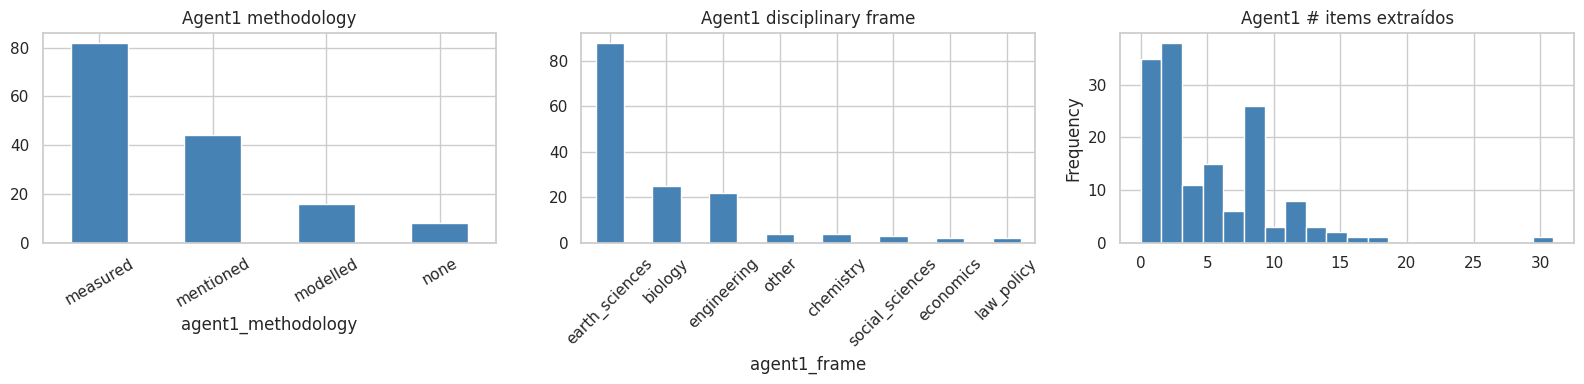

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df_eval['agent1_methodology'].value_counts().plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('Agent1 methodology')
axes[0].tick_params(axis='x', rotation=30)
df_eval['agent1_frame'].value_counts().plot.bar(ax=axes[1], color='steelblue')
axes[1].set_title('Agent1 disciplinary frame')
axes[1].tick_params(axis='x', rotation=45)
df_eval['agent1_n_items'].plot.hist(ax=axes[2], bins=20, color='steelblue')
axes[2].set_title('Agent1 # items extraídos')
plt.tight_layout()
plt.show()

In [14]:
# ¿Es la methodology del A1 un predictor útil de None?
tab = pd.crosstab(
    df_eval['agent1_methodology'],
    df_eval['pred_primary'].apply(lambda x: 'None' if x == 'None' else 'PBx'),
    margins=True,
)
print("Agent1 methodology vs decisión final del 14B:")
tab

Agent1 methodology vs decisión final del 14B:


pred_primary,None,PBx,All
agent1_methodology,,,
measured,15,67,82
mentioned,35,9,44
modelled,0,16,16
none,1,7,8
All,51,99,150


In [15]:
# Accuracy condicionada al # de items que extrajo el A1.
acc_by_items = (
    df_eval.assign(items_bin=pd.cut(df_eval['agent1_n_items'], bins=[-1,0,2,5,10,100],
                                    labels=['0','1-2','3-5','6-10','11+']))
    .groupby('items_bin', observed=True)
    .agg(n=('doc_id','size'), top1_acc=('ok_top1','mean'))
    .round(3)
)
acc_by_items

,n,top1_acc
items_bin,,
0,20,0.800
1-2,41,0.683
3-5,29,0.552
6-10,44,0.636
11+,16,0.500


## 7. Scorer determinista (kw_top_pbs)

¿La 1ª PB del scorer (`kw_top_pbs`) coincide con `pred_primary` y/o con `gt_pb`?

In [16]:
def kw_top1(s):
    if not isinstance(s, str) or not s.strip():
        return 'None'
    m = re.match(r'(PB\d)', s.strip())
    return m.group(1) if m else 'None'

df_eval['kw_top1'] = df_eval['kw_top_pbs'].apply(kw_top1)
kw_summary = pd.Series({
    'kw_top1 == pred_primary': (df_eval['kw_top1'] == df_eval['pred_primary']).mean(),
    'kw_top1 == gt_pb'       : (df_eval['kw_top1'] == df_eval['gt_pb']).mean(),
    'pred_primary == gt_pb (top-1)': df_eval['ok_top1'].mean(),
}).round(3)
kw_summary

kw_top1 == pred_primary          0.567
kw_top1 == gt_pb                 0.533
pred_primary == gt_pb (top-1)    0.640
dtype: float64

In [17]:
# Cuándo discrepan kw_top1 y el LLM, ¿quién acierta más vs GT?
disagree = df_eval[df_eval['kw_top1'] != df_eval['pred_primary']].copy()
if len(disagree):
    print(f'Casos donde kw_top1 != LLM primary: {len(disagree)}')
    print(f'  - LLM acierta GT: {(disagree["pred_primary"] == disagree["gt_pb"]).sum()}')
    print(f'  - KW  acierta GT: {(disagree["kw_top1"] == disagree["gt_pb"]).sum()}')
    print(f'  - Ninguno acierta: {((disagree["pred_primary"] != disagree["gt_pb"]) & (disagree["kw_top1"] != disagree["gt_pb"])).sum()}')
else:
    print('No hay desacuerdos')

Casos donde kw_top1 != LLM primary: 65
  - LLM acierta GT: 31
  - KW  acierta GT: 15
  - Ninguno acierta: 19


## 8. Timing

       agent1_time_s  agent3_time_s  total_time_s
count        158.000        153.000       158.000
mean           3.389          9.934        13.011
std            3.812         11.298        12.838
min            0.766          4.491         0.818
25%            1.080          5.695         7.069
50%            1.632          6.281         7.928
75%            3.250          7.699         9.884
max           16.219         70.845        76.404


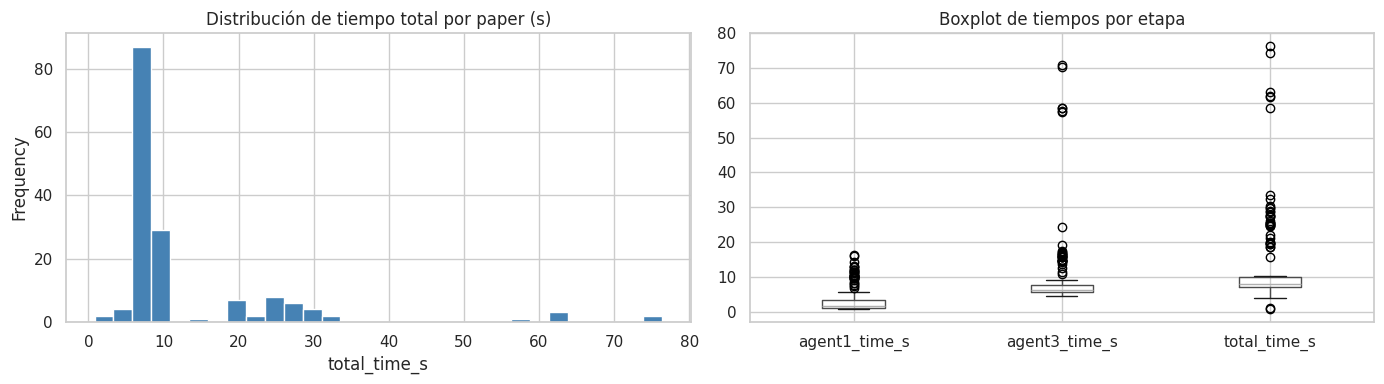

In [18]:
for col in ['agent1_time_s', 'agent3_time_s', 'total_time_s']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

timing = df[['agent1_time_s', 'agent3_time_s', 'total_time_s']].describe().round(3)
print(timing)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['total_time_s'].plot.hist(bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Distribución de tiempo total por paper (s)')
axes[0].set_xlabel('total_time_s')
df.boxplot(column=['agent1_time_s','agent3_time_s','total_time_s'], ax=axes[1])
axes[1].set_title('Boxplot de tiempos por etapa')
plt.tight_layout()
plt.show()

## 9. Inspección manual: peores casos

Muestreo de errores con su `llm_reasoning` para ver si el modelo se equivocó por mala decisión, prompt insuficiente, o GT discutible.

In [19]:
# Recomputamos errs aqui para que incluya kw_top1 (columna anadida en la celda 7).
errs = df_eval[~df_eval['ok_top1']].copy()
cols_view = ['doc_id','nombre_doc','gt_pb','gt_2nd','pred_primary','pred_secondary',
             'agent1_methodology','agent1_frame','kw_top1','llm_reasoning']

# (a) PB1 over-trigger: GT != PB1 pero pred == PB1.
mask_a = (errs['pred_primary'] == 'PB1') & (errs['gt_pb'] != 'PB1')
print('PB1 over-trigger (GT != PB1, pred = PB1):', int(mask_a.sum()))
errs.loc[mask_a, cols_view].head(8)

PB1 over-trigger (GT != PB1, pred = PB1): 8


,doc_id,nombre_doc,gt_pb,gt_2nd,pred_primary,pred_secondary,agent1_methodology,agent1_frame,kw_top1,llm_reasoning
26,82b2779f08ea,Effects of Ocean Acidification and Temperature Increases on the Photosynthesis of Tropical Reef ...,PB2,PB1,PB1,[PB2],measured,biology,PB1,The study measures the effects of CO2-driven ocean acidification and temperature increases on th...
47,fc1441e078b0,A scientific algorithm to simultaneously retrieve carbon monoxide and methane from TROPOMI onboa...,None,None,PB1,[],measured,earth_sciences,PB1,The research measures the atmospheric column-averaged dry air mole fractions of CO and CH4 using...
54,c95e30752adf,Synthesizing the evidence of nitrous oxide mitigation practices in agroecosystems.pdf,PB3,PB1,PB1,[PB4],measured,earth_sciences,None,The abstract focuses on the measurement and analysis of N2O emissions from agricultural practice...
84,c36b323b0cc5,The impact of oceanic heat transport on the atmospheric circulation.pdf,None,None,PB1,[],measured,earth_sciences,None,The abstract focuses on the impact of oceanic heat transport changes on global atmospheric circu...
86,efb1b08a09c7,Climatologically Significant Effects of Some Approximations in the Bulk Parameterizations of Tur...,None,None,PB1,[],measured,earth_sciences,None,The paper quantifies the impacts of various approximations and assumptions in bulk formula param...
106,3e5fff353a4c,Climatic conditions for emergence and flight of mountain pine beetle_ implications for long-dist...,PB7,PB1,PB1,[PB7],measured,earth_sciences,None,The abstract measures the climatic conditions influencing the emergence and flight of mountain p...
110,915bef103e53,Influence of contemporary warming on landscape-zonal systems of the East-European sub-continent_...,PB5,PB7,PB1,[PB7],modelled,earth_sciences,PB1,The abstract models the transformation of regional ecosystems under expected climatic changes us...
143,4f22542e7388,A suite of early Eocene (~ 55 Ma) climate model boundary conditions.pdf,None,None,PB1,[PB9],modelled,earth_sciences,None,"The abstract describes the construction of early Eocene climate model boundary conditions, focus..."


In [20]:
# (b) GT=None pero el modelo asigna un PB (falso positivo de PB).
case_b = errs[(errs['gt_pb'] == 'None') & errs['pred_primary'].isin(PB_CODES)][cols_view].head(8)
print('GT=None pero pred=PBx:', len(errs[(errs['gt_pb'] == 'None') & errs['pred_primary'].isin(PB_CODES)]))
case_b

GT=None pero pred=PBx: 15


,doc_id,nombre_doc,gt_pb,gt_2nd,pred_primary,pred_secondary,agent1_methodology,agent1_frame,kw_top1,llm_reasoning
9,8581e74341ad,Variabilities in PM2.5 and Black Carbon Surface Concentrations Reproduced by Aerosol Optical Pro...,None,None,PB9,[],measured,earth_sciences,PB9,The research measures and models the relationship between surface particulate matter (PM2.5) and...
32,84915f5956b8,Precision pH Sensor Based on WO3 Nanofiber-Polymer Composites and Differential Amplification.pdf,None,None,PB2,[],measured,engineering,PB1,The research focuses on the development and testing of a new potentiometric pH sensor with enhan...
42,080e222eec5e,UAS Chromatograph for Atmospheric Trace Species (UCATS) – a versatile instrument for trace gas m...,None,None,PB3,[PB1],measured,engineering,PB1,"The abstract describes the design and deployment of UCATS, a device for measuring atmospheric tr..."
47,fc1441e078b0,A scientific algorithm to simultaneously retrieve carbon monoxide and methane from TROPOMI onboa...,None,None,PB1,[],measured,earth_sciences,PB1,The research measures the atmospheric column-averaged dry air mole fractions of CO and CH4 using...
48,50137c06d495,Precipitation of salts in freezing seawater and ozone depletion events_ a status report.pdf,None,None,PB3,[],modelled,chemistry,PB3,The abstract focuses on simulating the chemical processes involved in polar marine boundary laye...
50,da697160487b,"Sensitivity of tracer transport to model resolution, prescribed meteorology and tracer lifetime ...",None,None,PB9,[],measured,earth_sciences,PB9,The research measures the transport of idealized tracers in different model resolutions and mete...
70,c882a9731d06,Producer Nutritional Quality Controls Ecosystem Trophic Structure.pdf,None,None,PB4,[],measured,biology,None,The research measures the impact of primary producer nutritional quality on ecosystem trophic st...
71,1a4300b95a49,Redistribution of soil metals and organic carbon via lateral flowpaths at the catchment scale in...,None,None,PB4,[],measured,earth_sciences,None,"The study quantifies chemical variations in soils, focusing on elements like Fe and Ce, which ar..."


In [21]:
# (c) GT=PBx pero el modelo dice None (recall fallido).
case_c = errs[(errs['gt_pb'] != 'None') & (errs['pred_primary'] == 'None')][cols_view].head(8)
print('GT=PBx pero pred=None:', len(errs[(errs['gt_pb'] != 'None') & (errs['pred_primary'] == 'None')]))
case_c

GT=PBx pero pred=None: 15


,doc_id,nombre_doc,gt_pb,gt_2nd,pred_primary,pred_secondary,agent1_methodology,agent1_frame,kw_top1,llm_reasoning
14,5194c7c1714e,Climate change and spring-fruiting fungi.pdf,PB1,None,None,[PB7],measured,biology,PB1,"The abstract focuses on the study of spring-fruiting fungi in relation to climate change, but it..."
19,ca6e200d678b,Variability in the speed of the Brewer–Dobson circulation as observed by Aura_MLS.pdf,PB1,None,None,[],measured,earth_sciences,None,The research measures the speed of the Brewer-Dobson circulation (BDC) using Aura/MLS stratosphe...
22,dbde52e667aa,Climate Change in the North Pacific Using Ice-Rafted Detritus as a Climatic Indicator.pdf,PB1,None,None,[],measured,earth_sciences,None,The abstract measures variations in weight percent of the grain size fraction greater than 250 j...
66,6039788ff154,Environmental mutagenesis during the end-Permian ecological crisis.pdf,PB3,None,None,[],measured,earth_sciences,None,The abstract focuses on the study of environmental mutagenesis during the end-Permian ecological...
74,491cd02d01cd,Atlantic Geoscience Society.pdf,PB7,None,None,[],mentioned,earth_sciences,None,The abstract focuses on the geological and chemical analysis of Neoproterozoic igneous units in ...
82,61c5ef71efb6,Legal Lamination to Transboundary Movement of Plastic Pollutants.pdf,PB8,None,None,[],mentioned,law_policy,None,Consensus: Agent1 (0 items + non-bio frame) AND scorer (no PB matched).
83,9275249d37b1,"History, Status, and Future of Oyster Culture in France.pdf",PB8,None,None,[],mentioned,biology,None,"The abstract focuses on the history and current production of oyster species in France, specific..."
91,662818aff829,Synoptic Tactics_ Mapping Territorial Transgressions.pdf,PB6,None,None,[],mentioned,earth_sciences,None,The abstract discusses the challenges and opportunities of transboundary environmental managemen...


## 10. Exportar resultados anotados

Guarda el merge completo con flags de error/correctness para revisar fuera del notebook.

In [22]:
out_path = ROOT / 'nlp' / 'llm' / 'outputs' / 'pipeline_cascada' / 'pipeline_cascada_eval.csv'
df_export = df_eval[[
    'doc_id','nombre_doc','route',
    'gt_pb','gt_2nd','gt_3rd',
    'pred_primary','pred_secondary','llm_primary_conf','llm_rejected_pbs',
    'ok_top1','ok_top2','ml_recall',
    'agent1_methodology','agent1_frame','agent1_n_items',
    'kw_top_pbs','kw_top1',
    'agent1_time_s','agent3_time_s','total_time_s',
    'llm_reasoning',
]].copy()
df_export.to_csv(out_path, index=False)
print(f'Exportado -> {out_path}')
print(f'Filas: {len(df_export)}')

Exportado -> /home/sortmon/UPV_EARTH_PROYECTOIII/nlp/llm/outputs/pipeline_cascada/pipeline_cascada_eval.csv
Filas: 150


## 11. Ablation: contribución del Agente 4 (critic)

Comparamos las decisiones ANTES del critic (`llm_primary_pb`) vs DESPUÉS (`final_primary_pb`).
Esto cuantifica el aporte específico del verificador asimétrico — la columna que el proyecto puede defender como contribución del diseño multi-agente.

In [ ]:
if 'final_primary_pb' not in df.columns:
    print('Este CSV no tiene Agente 4 (final_primary_pb ausente). Re-corre el pipeline para activar el ablation.')
else:
    df_a = df_eval.copy()
    df_a['pre_critic']  = df_a['llm_primary_pb'].replace('', 'None')
    df_a['post_critic'] = df_a['final_primary_pb'].replace('', pd.NA).fillna(df_a['pre_critic'])

    base_top1  = (df_a['pre_critic']  == df_a['gt_pb']).mean()
    final_top1 = (df_a['post_critic'] == df_a['gt_pb']).mean()
    flips = df_a[df_a['pre_critic'] != df_a['post_critic']].copy()
    flips['delta'] = flips.apply(
        lambda r: '+1' if r['post_critic'] == r['gt_pb']
                       else ('-1' if r['pre_critic'] == r['gt_pb'] else '0'),
        axis=1,
    )

    print(f'Top-1 SIN critic    : {base_top1:.3f}  ({(df_a["pre_critic"] == df_a["gt_pb"]).sum()} / {len(df_a)})')
    print(f'Top-1 CON critic    : {final_top1:.3f}  ({(df_a["post_critic"] == df_a["gt_pb"]).sum()} / {len(df_a)})')
    print(f'Delta absoluto      : {final_top1 - base_top1:+.3f}')
    print(f'Filas modificadas   : {len(flips)}  (rescates +1: {(flips["delta"]=="+1").sum()}  rupturas -1: {(flips["delta"]=="-1").sum()}  neutros: {(flips["delta"]=="0").sum()})')

    if len(flips):
        # Soporta tanto la integración nativa (agent4_*) como el retroactivo (critic_*).
        cand_cols = ['doc_id','nombre_doc','gt_pb','pre_critic','post_critic','delta']
        for extra in ('agent4_confidence', 'critic_confidence',
                       'agent4_reasoning', 'critic_reasoning'):
            if extra in flips.columns:
                cand_cols.append(extra)
        print('\nDetalle de los flips:')
        print(flips[cand_cols].to_string())